Name - Jenish Prakash Singh
ID - 2408948

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# 1. Import the drive module and mount it
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Define Dataset Path
DATASET_PATH = '/content/drive/MyDrive/vision_task/natural_images/'

print("Dataset path set to:", DATASET_PATH)

Dataset path set to: /content/drive/MyDrive/vision_task/natural_images/


In [4]:
# 1. Dataset Distribution
classes = os.listdir(DATASET_PATH)
class_counts = {c: len(os.listdir(os.path.join(DATASET_PATH, c))) for c in classes}
print("Classes:", classes)
print("Image Count per Class:", class_counts)

Classes: ['airplane', 'car', 'flower', 'cat', 'fruit', 'motorbike', 'person', 'dog']
Image Count per Class: {'airplane': 727, 'car': 968, 'flower': 843, 'cat': 885, 'fruit': 1000, 'motorbike': 788, 'person': 986, 'dog': 702}


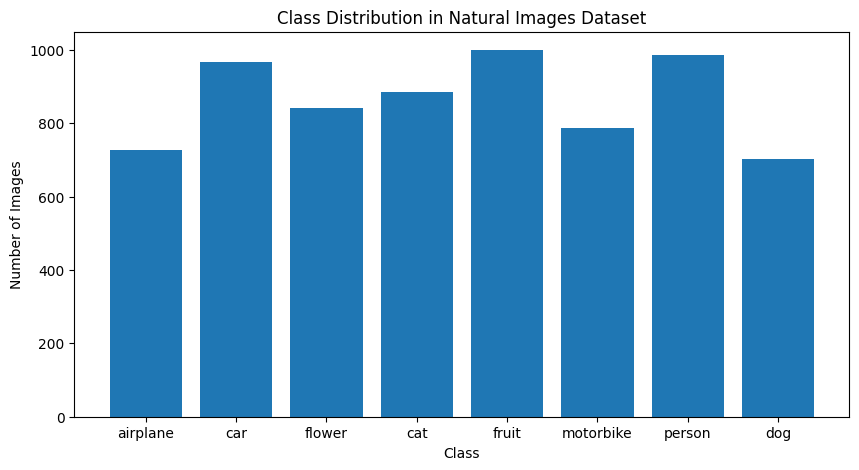

In [5]:
# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution in Natural Images Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [6]:
# ==============================================================================
# Preprocessing and Data Generators (Part A: 128x128)
# ==============================================================================
# Base augmentation plan as per proposal
train_datagen_A = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 80/20 Stratified Split
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen_A = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator_A = train_datagen_A.flow_from_directory(
    DATASET_PATH,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_A = val_datagen_A.flow_from_directory(
    DATASET_PATH,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.


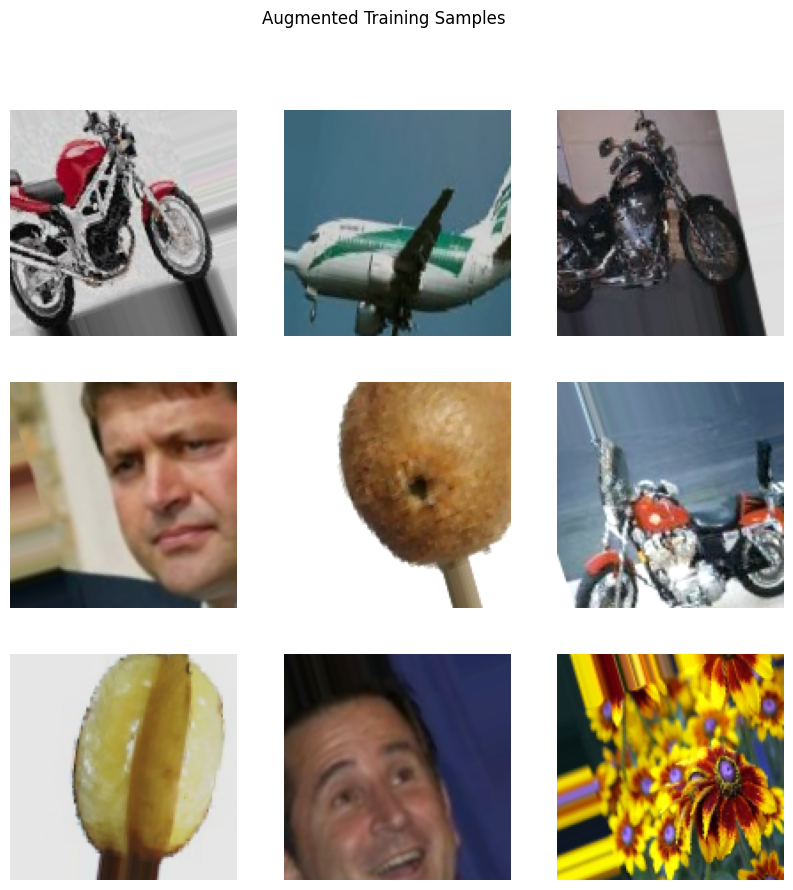

In [7]:
# Visualize Augmented Samples
images, labels = next(train_generator_A)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("Augmented Training Samples")
plt.show()

In [8]:
# ==============================================================================
# Helper Function for Plotting
# ==============================================================================
def plot_history(history, title="Model Performance"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

In [9]:
# ==============================================================================
# Part A: Baseline CNN Model (3 Conv + 3 FC)
# ==============================================================================
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(8, activation='softmax')
])

baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,313,416 (12.64 MB)

 Trainable params: 3,313,416 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Baseline Model
print("\n--- Training Baseline Model ---")

# Recompile the baseline_model to match the number of classes detected by the generator
# The generator reported finding 1 class, but the model's output layer was set for 8.
# If your dataset is intended to have more than 1 class, you should verify the DATASET_PATH
# and directory structure (e.g., DATASET_PATH should point to the parent of class folders).
num_classes = train_generator_A.num_classes
if baseline_model.output_shape[-1] != num_classes:
    print(f"Warning: Adjusting baseline_model output layer from {baseline_model.output_shape[-1]} to {num_classes} classes to match generator.")
    baseline_model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax') # Adjusted to match generator's num_classes
    ])
    baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    baseline_model.summary()

history_baseline = baseline_model.fit(
    train_generator_A,
    validation_data=val_generator_A,
    epochs=15
)
plot_history(history_baseline, "Baseline CNN")


--- Training Baseline Model ---
Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 1807s 10s/step - accuracy: 0.5369 - loss: 1.2209 - val_accuracy: 0.6812 - val_loss: 1.0749
Epoch 2/15
 47/173 ━━━━━━━━━━━━━━━━━━━━ 1:29 708ms/step - accuracy: 0.7580 - loss: 0.6687

In [ ]:
# ==============================================================================
# Part A: Deeper CNN with Regularization (6 Conv + BN + Dropout)
# ==============================================================================
def create_deeper_model(optimizer='adam', include_dropout=True):
    model = Sequential()
    model.add(Input(shape=(128, 128, 3)))

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    if include_dropout: model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    if include_dropout: model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    if include_dropout: model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    if include_dropout: model.add(Dropout(0.5))
    model.add(Dense(8, activation='softmax'))

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

deeper_model_adam = create_deeper_model(optimizer=Adam(learning_rate=0.001))
deeper_model_adam.summary()

In [ ]:
# Train Deeper Model (Adam)
print("\n--- Training Deeper Model (Adam) ---")
history_deeper_adam = deeper_model_adam.fit(
    train_generator_A,
    validation_data=val_generator_A,
    epochs=15
)
plot_history(history_deeper_adam, "Deeper CNN (Adam)")

In [ ]:
# ==============================================================================
# Experimentation: SGD vs Adam & Ablation
# ==============================================================================
print("\n--- Training Deeper Model (SGD) ---")
deeper_model_sgd = create_deeper_model(optimizer=SGD(learning_rate=0.01, momentum=0.9))
history_deeper_sgd = deeper_model_sgd.fit(
    train_generator_A, validation_data=val_generator_A, epochs=15
)

print("\n--- Training Deeper Model (Ablation: No Dropout) ---")
ablation_model = create_deeper_model(optimizer='adam', include_dropout=False)
history_ablation = ablation_model.fit(
    train_generator_A, validation_data=val_generator_A, epochs=15
)

In [ ]:
# ==============================================================================
# Part B: Transfer Learning (VGG16) - Requires 224x224 Input
# ==============================================================================
train_generator_B = train_datagen_A.flow_from_directory(
    DATASET_PATH, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training'
)
val_generator_B = val_datagen_A.flow_from_directory(
    DATASET_PATH, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation', shuffle=False
)

In [ ]:
# Load VGG16 Base
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False # Freeze the base

tl_model = Sequential([
    vgg_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

tl_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

print("\n--- Training Transfer Learning Model (VGG16) ---")
history_tl = tl_model.fit(
    train_generator_B,
    validation_data=val_generator_B,
    epochs=10
)
plot_history(history_tl, "Transfer Learning (VGG16)")

In [ ]:
# ==============================================================================
# Evaluation & Confusion Matrix (Using best model, e.g., Transfer Learning)
# ==============================================================================
print("\n--- Final Evaluation ---")
val_generator_B.reset()
predictions = tl_model.predict(val_generator_B)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator_B.classes

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - VGG16')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()